
# Denoise images using the Marcenko-Pastur PCA algorithm

The PCA-based denoising algorithm exploits the redundancy across the
diffusion-weighted images :footcite:p:`Manjon2013`, :footcite:p:`Veraart2016b`.
This algorithm has been shown to provide an optimal compromise between noise
suppression and loss of anatomical information for different techniques such as
DTI :footcite:p:`Manjon2013`, spherical deconvolution :footcite:p:`Veraart2016b`
and DKI :footcite:p:`NetoHenriques2018`.

The basic idea behind the PCA-based denoising algorithms is to remove the
components of the data that are classified as noise. The Principal Components
classification can be performed based on prior noise variance estimates
:footcite:p:`Manjon2013`
(see `denoise_localpca<sphx_glr_examples_built_preprocessing_denoise_localpca.py>`)
or automatically based on the Marchenko-Pastur distribution
:footcite:p:`Veraart2016b`. In addition to noise suppression, the PCA algorithm
can be used to get the standard deviation of the noise
:footcite:p:`Veraart2016b`.

In the following example, we show how to denoise diffusion MRI images and
estimate the noise standard deviation using the PCA algorithm based
on the Marcenko-Pastur distribution :footcite:p:`Veraart2016b`

Let's load the necessary modules


In [13]:
# load general modules
from time import time

import matplotlib.pyplot as plt
import numpy as np

# load other dipy's functions that will be used for auxiliary analysis
from dipy.core.gradients import gradient_table

# load functions to fetch data for this example
from dipy.data import get_fnames

# load main pca function using Marcenko-Pastur distribution
from dipy.denoise.localpca import mppca
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, save_nifti
import dipy.reconst.dki as dki
from dipy.segment.mask import median_otsu

For this example, we use fetch to download a multi-shell dataset which was
kindly provided by Hansen and Jespersen (more details about the data are
provided in their paper :footcite:p:`Hansen2016a`). The total size of the
downloaded data is 192 MBytes, however you only need to fetch it once.



In [14]:
dwi_fname, dwi_bval_fname, dwi_bvec_fname, _ = get_fnames(name="cfin_multib")
data, affine = load_nifti(dwi_fname)
bvals, bvecs = read_bvals_bvecs(dwi_bval_fname, dwi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

[2026-09-16 11:19:20][dipy] INFO: Dataset is already in place. If you want to fetch it again please first remove the folder /home/falconnier/.dipy/cfin_multib 
[2026-09-16 11:19:20][dipy] INFO: This data was provided by Brian Hansen and Sune Jespersen More details about the data are available in their paper:  https://www.nature.com/articles/sdata201672


For the sake of simplicity, we only select two non-zero b-values for this
example.



In [15]:
bvals = gtab.bvals

bvecs = gtab.bvecs

sel_b = np.logical_or(np.logical_or(bvals == 0, bvals == 1000), bvals == 2000)

data = data[..., sel_b]

gtab = gradient_table(bvals[sel_b], bvecs=bvecs[sel_b])

print(data.shape)

(96, 96, 19, 67)


As one can see from its shape, the selected data contains a total of 67
volumes of images corresponding to all the diffusion gradient directions
of the selected b-values.

The PCA denoising using the Marchenko-Pastur distribution can be performed by
calling the function ``mppca``:



In [16]:
t = time()

denoised_arr = mppca(data, patch_radius=2)

print("Time taken for local MP-PCA ", -t + time())

KeyboardInterrupt: 

Internally, the ``mppca`` algorithm denoises the diffusion-weighted data
using a 3D sliding window which is defined by the variable patch_radius.
In total, this window should comprise a larger number of voxels than the
number of diffusion-weighted volumes. Since our data has a total of 67
volumes, the patch_radius is set to 2 which corresponds to a 5x5x5 sliding
window comprising a total of 125 voxels.



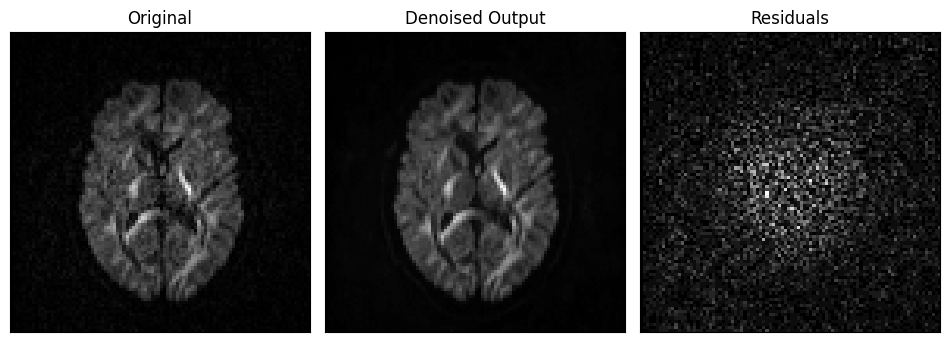

In [ ]:
# To assess the performance of the Marchenko-Pastur PCA denoising algorithm,
# an axial slice of the original data, denoised data, and residuals are
# plotted below:

sli = data.shape[2] // 2
gra = data.shape[3] - 1
orig = data[:, :, sli, gra]
den = denoised_arr[:, :, sli, gra]
rms_diff = np.sqrt((orig - den) ** 2)

fig1, ax = plt.subplots(1, 3, figsize=(12, 6), subplot_kw={"xticks": [], "yticks": []})

fig1.subplots_adjust(hspace=0.3, wspace=0.05)

ax.flat[0].imshow(orig.T, cmap="gray", interpolation="none", origin="lower")
ax.flat[0].set_title("Original")
ax.flat[1].imshow(den.T, cmap="gray", interpolation="none", origin="lower")
ax.flat[1].set_title("Denoised Output")
ax.flat[2].imshow(rms_diff.T, cmap="gray", interpolation="none", origin="lower")
ax.flat[2].set_title("Residuals")

fig1.savefig("denoised_mppca.png")

.. rst-class:: centered small fst-italic fw-semibold

The noise suppression can be visually appreciated by comparing the original
data slice (left panel) to its denoised version (middle panel). The
difference between original and denoised data showing only random noise
indicates that the data's structural information is preserved by the PCA
denoising algorithm (right panel).


Below we show how the denoised data can be saved.



In [ ]:
save_nifti("denoised_mppca.nii.gz", denoised_arr, affine)

Additionally, we show how the PCA denoising algorithm affects different
diffusion measurements. For this, we run the diffusion kurtosis model
below on both original and denoised versions of the data:



In [ ]:
dkimodel = dki.DiffusionKurtosisModel(gtab)

maskdata, mask = median_otsu(data, vol_idx=[0, 1], median_radius=4, numpass=2, dilate=1)

dki_orig = dkimodel.fit(data, mask=mask)
dki_den = dkimodel.fit(denoised_arr, mask=mask)

We use the following code to plot the MD, FA and MK estimates from the two
data fits:



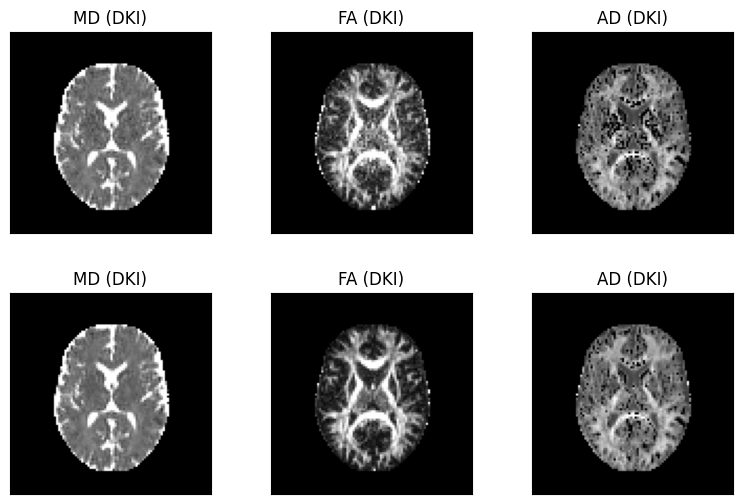

In [ ]:
FA_orig = dki_orig.fa
FA_den = dki_den.fa
MD_orig = dki_orig.md
MD_den = dki_den.md
MK_orig = dki_orig.mk(min_kurtosis=0, max_kurtosis=3)
MK_den = dki_den.mk(min_kurtosis=0, max_kurtosis=3)


fig2, ax = plt.subplots(2, 3, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})

fig2.subplots_adjust(hspace=0.3, wspace=0.03)

ax.flat[0].imshow(
    MD_orig[:, :, sli].T, cmap="gray", vmin=0, vmax=2.0e-3, origin="lower"
)
ax.flat[0].set_title("MD (DKI)")
ax.flat[1].imshow(FA_orig[:, :, sli].T, cmap="gray", vmin=0, vmax=0.7, origin="lower")
ax.flat[1].set_title("FA (DKI)")
ax.flat[2].imshow(MK_orig[:, :, sli].T, cmap="gray", vmin=0, vmax=1.5, origin="lower")
ax.flat[2].set_title("AD (DKI)")
ax.flat[3].imshow(MD_den[:, :, sli].T, cmap="gray", vmin=0, vmax=2.0e-3, origin="lower")
ax.flat[3].set_title("MD (DKI)")
ax.flat[4].imshow(FA_den[:, :, sli].T, cmap="gray", vmin=0, vmax=0.7, origin="lower")
ax.flat[4].set_title("FA (DKI)")
ax.flat[5].imshow(MK_den[:, :, sli].T, cmap="gray", vmin=0, vmax=1.5, origin="lower")
ax.flat[5].set_title("AD (DKI)")
plt.show()
fig2.savefig("denoised_dki.png")

.. rst-class:: centered small fst-italic fw-semibold

In the above figure, the DKI maps obtained from the original data are shown
in the upper panels, while the DKI maps from the denoised data are shown in
the lower panels. Substantial improvements in measurement robustness can be
visually appreciated, particularly for the FA and MK estimates.


## Noise standard deviation estimation using the Marchenko-Pastur PCA algorithm

As mentioned above, the Marcenko-Pastur PCA algorithm can also be used to
estimate the image's noise standard deviation (std). The noise std
automatically computed from the ``mppca`` function can be returned by
setting the optional input parameter ``return_sigma`` to True.



In [ ]:
denoised_arr, sigma = mppca(data, patch_radius=2, return_sigma=True)

Let's plot the noise standard deviation estimate:



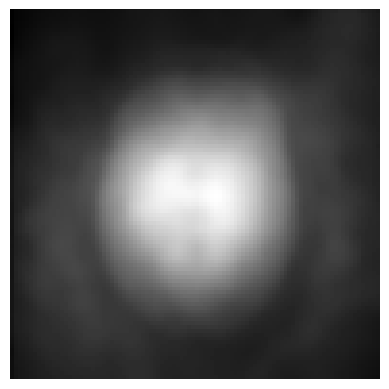

In [ ]:
fig3 = plt.figure("PCA Noise standard deviation estimation")
plt.imshow(sigma[..., sli].T, cmap="gray", origin="lower")
plt.axis("off")
plt.show()
fig3.savefig("pca_sigma.png")

.. rst-class:: centered small fst-italic fw-semibold

The above figure shows that the Marchenko-Pastur PCA algorithm computes a 3D
spatial varying noise level map. To obtain the mean noise std across all
voxels, you can use the following lines of code:



In [ ]:
mean_sigma = np.mean(sigma[mask])

print(mean_sigma)

4.6833835


Below we use this mean noise level estimate to compute the nominal SNR of
the data (i.e. SNR at b-value=0):



In [ ]:
b0 = denoised_arr[..., 0]

mean_signal = np.mean(b0[mask])

snr = mean_signal / mean_sigma

print(snr)

34.5618108119213


### References

.. footbibliography::




.. include:: ../../links_names.inc


